In [1]:
import torch 
import torch.nn.functional as F
from src.model import ResNetTransfer
from src.data_setup import get_test_data_transformed
from torch.utils.data import DataLoader
from src.utils import tensor_to_pil, evaluation
from torchmetrics import Accuracy

device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
IMAGE_SIZE = 224
N_CLASSES = 2

weights = torch.load("../models/resnet_finetuned.pth")
model = ResNetTransfer(n_classes=N_CLASSES)
model.load_state_dict(weights)
model = model.to(device)

# **1. Como testar o modelo?**

Você poderá escolher as imagens que serão usadas para testar o modelo.

**Caso você tenha algum cachorro ou gato tire fotos dele e teste o modelo com elas!**

## **1.1 Primeiro passo**

Antes de tudo, caso não tenha feito ainda, execute o seguinte comando para iniciar o treinamento e salvamento do modelo.

```
uv run train.py
```

## **1.2 Carregamento das imagens**

Crie um diretório dentro de ``data/`` chamado **evaluation_set**.

```text
├── data/      
│   ├── evaluation_set/           
│   ├── test_set/            
│   └── training_set/            
```

Após a criação essa etapa, crie outros **dois subdiretórios** de ``evaluation_set`` chamados de **dogs** e **cats**.

A **estrutura** do diretório deverá ficar da seguinte maneira.

```text
├── evaluation_set/      
│   ├── cats/                      
│   └── dogs/     
```

Finalmente, coloque as suas imagens organizadas nesses dois subdiretórios.

A **estrutura** dos subdiretórios deverá ficar da seguinte maneira.

```text
├── evaluation_set/      
│     ├── cats
│     │   ├── gato1.jpeg
│     │   ├── gato2.jpeg
│     │   ├── gato3.jpeg
│     │   ├── gato4.jpeg
│     │   └── gato5.jpeg
│     └── dogs
│         ├── cachorro1.jpeg
│         ├── cachorro2.jpeg
│         ├── cachorro3.jpeg
│         ├── cachorro4.jpeg
│         ├── cachorro5.jpeg

```

In [11]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

root_data = "../data/evaluation_set"

evaluation_data = get_test_data_transformed(root=root_data, image_size=IMAGE_SIZE, mean=imagenet_mean, std=imagenet_std)
evaluation_loader = DataLoader(evaluation_data)

/home/koheiseko/Documents/projects/cat-dog-classification/.venv/lib64/python3.13/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [13]:
weights = torch.load("../models/resnet_finetuned.pth")
model = ResNetTransfer(n_classes=N_CLASSES)
model.load_state_dict(weights)
model = model.to(device)

accuracy = Accuracy(task="multiclass", num_classes=2).to(device)

/home/koheiseko/Documents/projects/cat-dog-classification/src/utils.py:29: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  prob = F.softmax(y_pred)


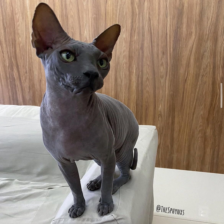

O animal na imagem é um gato


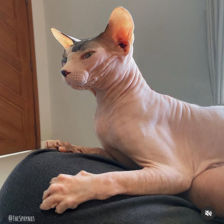

O animal na imagem é um gato


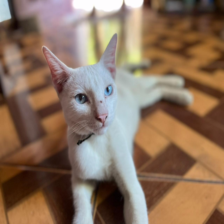

O animal na imagem é um gato


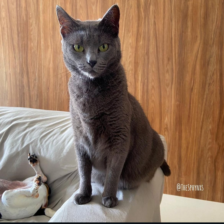

O animal na imagem é um gato


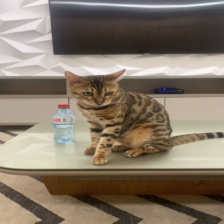

O animal na imagem é um gato


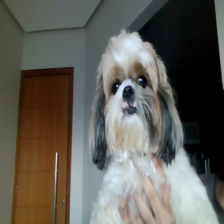

O animal na imagem é um cachorro


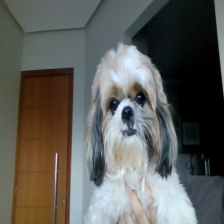

O animal na imagem é um cachorro


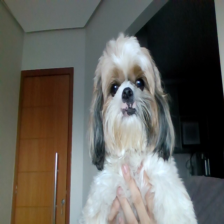

O animal na imagem é um cachorro


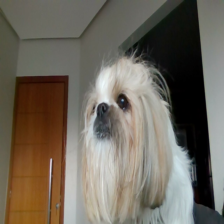

O animal na imagem é um cachorro


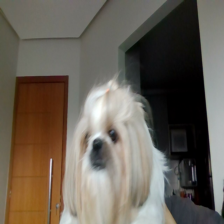

O animal na imagem é um cachorro


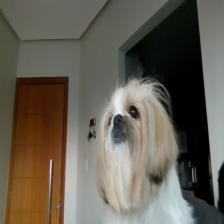

O animal na imagem é um cachorro


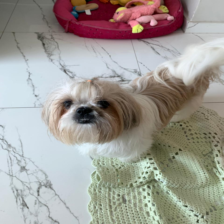

O animal na imagem é um cachorro


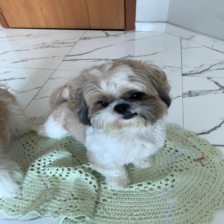

O animal na imagem é um cachorro


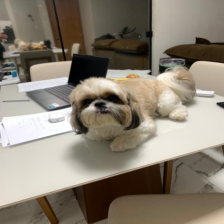

O animal na imagem é um cachorro


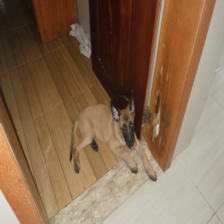

O animal na imagem é um cachorro


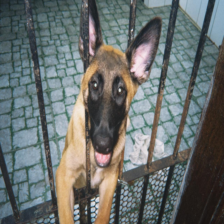

O animal na imagem é um cachorro


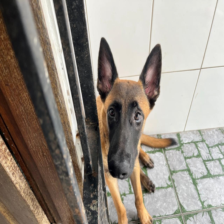

O animal na imagem é um cachorro


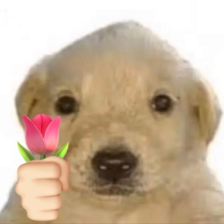

O animal na imagem é um cachorro


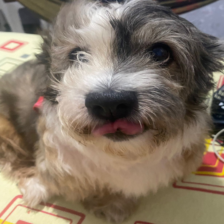

O animal na imagem é um cachorro


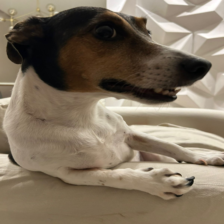

O animal na imagem é um cachorro
A acurácia do modelo nos dados de avaliação foi de 100.0%


In [14]:
acc_eval = evaluation(model, evaluation_loader, accuracy, device, imagenet_mean, imagenet_std)
print(f"A acurácia do modelo nos dados de avaliação foi de {acc_eval * 100}%")